# Predicting Traffic Collision Severity for NYC Emergency Medical Services



## Team

- **Adelina Dunina** (GitHub: Adelina2302) — *Point of Contact*
- **name
- **name

## Overview

**What are we trying to do?** We are building a system that predicts whether a traffic collision in New York City will result in injuries or fatalities. The goal is to help emergency medical teams know in advance which areas and times are most dangerous, so they can position ambulances and staff where they are most likely to be needed.

**What is new in our approach?** Current collision analysis in NYC and other cities relies primarily on retrospective hotspot mapping — identifying where crashes occurred in the past using GIS-based density analysis [1][2]. While useful, these methods cannot predict future risk or account for temporal variation. Some recent studies have applied spatial clustering (K-means, DBSCAN) to identify high-risk zones [3], but these ignore when crashes happen. Time-series approaches like ARIMA [4] capture temporal patterns but miss the spatial dimension. Our approach integrates both: we combine temporal features (hour, day of week, season), spatial features (borough, coordinates), and crash characteristics (vehicle types, contributing factors) into unified predictive models that forecast future collision severity using a temporal train/test split. We also focus specifically on one stakeholder's operational needs rather than producing general-purpose analysis.

**Who cares?** Our primary stakeholder is **NYC Emergency Medical Services (EMS)**. Based on instructor feedback from Checkpoint 1, we narrowed our focus from four stakeholder groups to one. EMS needs to strategically position ambulances and medical personnel to minimize response times to serious collisions. They need predictions that identify *when* and *where* severe injury crashes are most likely, ideally updated by shift or hourly. For EMS, recall matters more than precision — failing to position resources near an actual severe crash has life-or-death consequences, while occasionally over-deploying is an acceptable cost.

**What changed since Checkpoint 1:** Following instructor feedback, we (1) narrowed to a single stakeholder (EMS) and (2) plan to explore temporal models (LSTM) in addition to our current traditional ML approach.

## Data

### Source and Credibility

Our primary dataset is the **NYC Motor Vehicle Collisions — Crashes** dataset from the [NYC Open Data Portal](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data). This is official NYPD data collected from police reports (MV-104AN forms) filed for every collision in NYC where someone is injured, killed, or where there is at least $1,000 in property damage. The dataset is updated regularly by the city and includes metadata explaining each field.

Our working subset contains **375,025 records** spanning **February 2022 through January 2026**, with 29 original columns covering temporal information (date, time), spatial information (borough, coordinates, street names), impact data (injuries and deaths by road user type), contributing factors, and vehicle types.

### Exploratory Data Analysis

We conducted extensive EDA to understand collision patterns across temporal, spatial, and severity dimensions.

#### Temporal Patterns

Collisions follow strong temporal patterns that are directly useful for EMS resource planning. The peak hour for collisions is **5:00 PM (17:00)** with 23,411 crashes, while the safest hour is **3:00 AM** with only 6,818 — a 3.4x difference. **Friday** is the most dangerous day with 58,561 collisions. Seasonally, **May** sees the most crashes (34,287) while February has the fewest. These patterns suggest EMS should increase staffing during evening rush hours and on Fridays.

The following chart shows the hourly distribution of collisions:

In [2]:
%%capture --no-display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('../data/collisions_clean.csv')
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

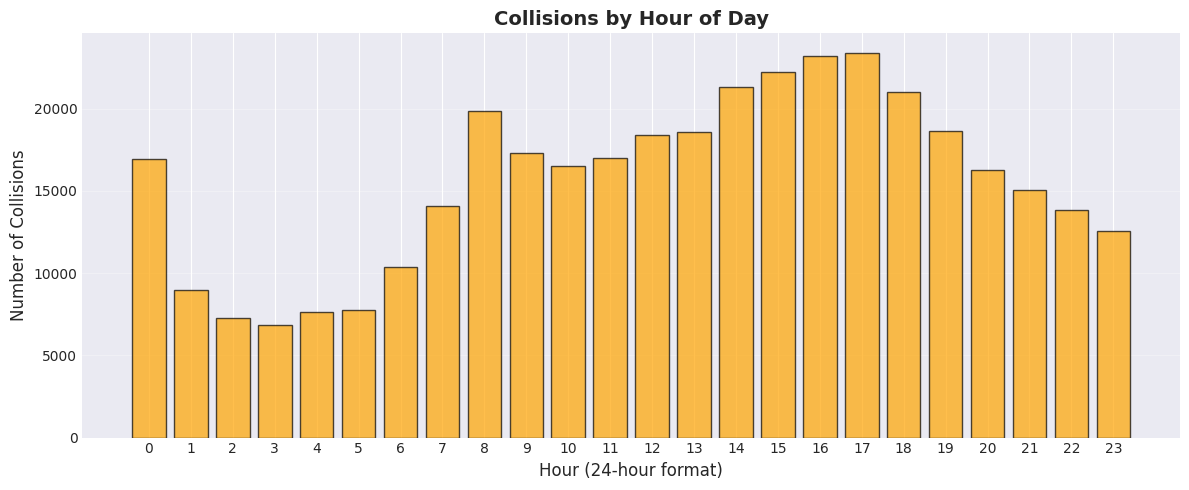

In [3]:
# Collisions by hour of day
hourly = df['hour'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color='orange', alpha=0.7, edgecolor='black')
plt.title('Collisions by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (24-hour format)', fontsize=12)
plt.ylabel('Number of Collisions', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Spatial Patterns

Brooklyn leads all boroughs with 93,151 collisions (34.8% of geolocated crashes), followed by Queens (71,687), Manhattan (48,948), Bronx (42,789), and Staten Island (10,899). Notably, 28.7% of records are missing borough information — a data quality issue we addressed in preprocessing. The severity breakdown is relatively consistent across boroughs, with fatality rates ranging from 0.20% (Queens) to 0.25% (Bronx and Staten Island).

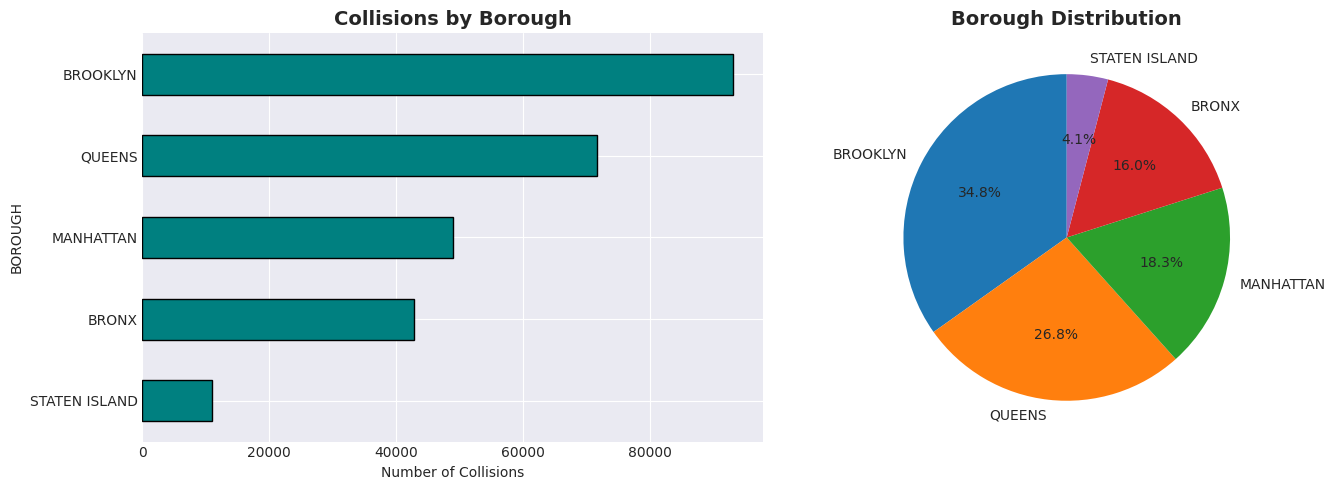

In [4]:
# Borough distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

borough_counts = df['BOROUGH'].value_counts()
borough_counts = borough_counts[borough_counts.index != 'Unknown']

borough_counts.plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Collisions by Borough', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Collisions')
axes[0].invert_yaxis()

borough_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Borough Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### Severity Distribution

The severity distribution reveals a key challenge for our modeling task: **58.1%** of collisions result in property damage only, **41.7%** involve injuries, and just **0.27%** are fatal (1,003 out of 375,025). This means our binary target (Injury/Fatal vs. Property Damage Only) has a roughly 42:58 class split — not extreme imbalance, but the fatal cases that matter most to EMS are very rare. The pedestrian casualty rate is 9.5% and cyclist casualty rate is 5.5%, indicating that vulnerable road users are disproportionately affected.

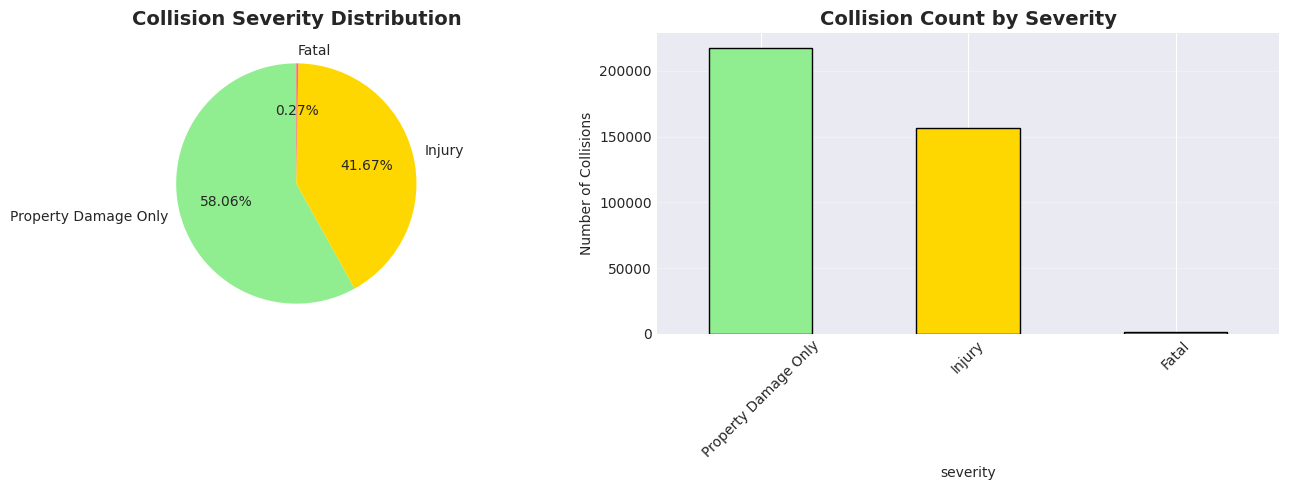

In [5]:
# Severity distribution
severity_counts = df['severity'].value_counts()
colors_severity = ['#90EE90', '#FFD700', '#FF6B6B']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
severity_counts.plot(kind='pie', ax=axes[0], autopct='%1.2f%%',
                     colors=colors_severity, startangle=90)
axes[0].set_title('Collision Severity Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

severity_counts.plot(kind='bar', ax=axes[1], color=colors_severity, edgecolor='black')
axes[1].set_title('Collision Count by Severity', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Collisions')
axes[1].set_xticklabels(severity_counts.index, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Contributing Factors

After removing the uninformative "Unspecified" label (which accounted for 24.7% of primary factors), the top contributing factors are **Driver Inattention/Distraction** (92,484 cases), **Failure to Yield Right-of-Way** (25,839), and **Following Too Closely** (22,766). We grouped these into higher-level categories for modeling: Distracted Driving (94,414), Improper Lane Use/Passing (36,651), and Failure to Yield (25,839) are the three largest categories. The dominance of distracted driving suggests this factor will be an important predictor of collision severity.

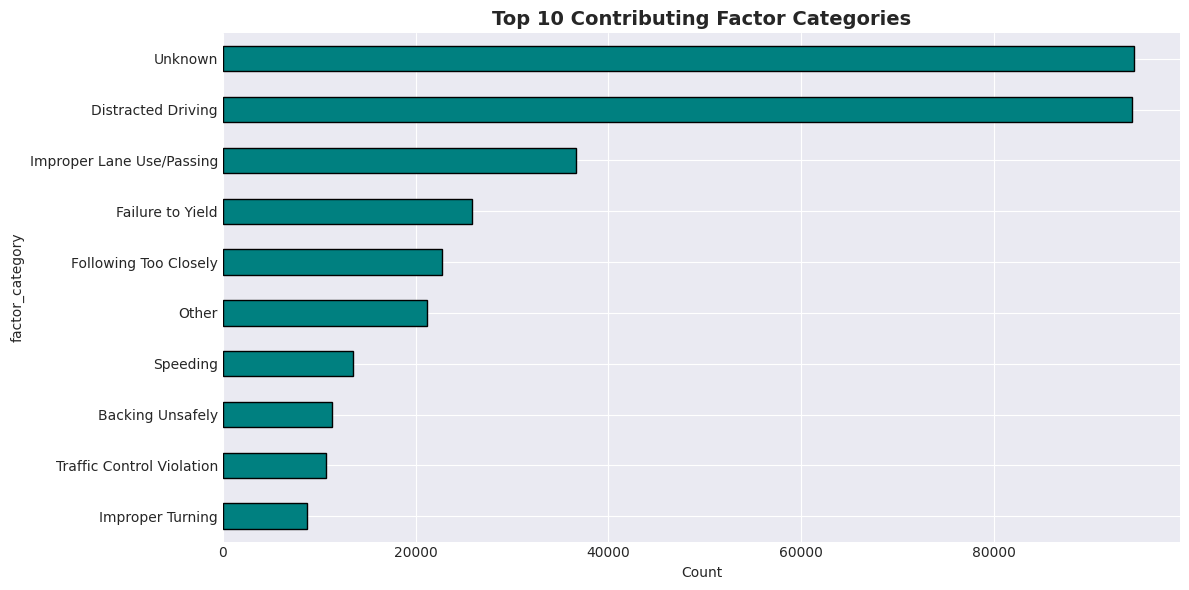

In [6]:
# Contributing factor categories
factor_counts = df['factor_category'].value_counts().head(10)
plt.figure(figsize=(12, 6))
factor_counts.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Contributing Factor Categories', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Preprocessing

The raw dataset required substantial preprocessing to become analysis-ready. We addressed four main issues:

### 1. Coordinate Formatting and Missing Values

The raw data stored latitude and longitude with European-style comma decimals (e.g., `40,719456` instead of `40.719456`). After converting to proper floats, we identified 28,415 records missing coordinates (including 4,719 that fell outside NYC's geographic bounds, which we treated as invalid).

### 2. Geocoding Missing Coordinates

Rather than using external geocoding APIs (which would be extremely slow at ~1 request/second for thousands of records), we developed a **self-lookup approach** using the dataset's own intersection data:

In [7]:
# Our geocoding strategy and results
print('GEOCODING RESULTS SUMMARY')
print('=' * 50)
print(f'Missing coordinates before:  28,415')
print(f'Filled via forward match:     3,678')
print(f'Filled via reverse match:     3,264')
print(f'Filled via ZIP centroids:     8,055')
print(f'Total recovered:             14,997')
print(f'Still missing after:         13,418 (3.6%)')
print(f'Final coordinate coverage:    92.7%')

GEOCODING RESULTS SUMMARY
Missing coordinates before:  28,415
Filled via forward match:     3,678
Filled via reverse match:     3,264
Filled via ZIP centroids:     8,055
Total recovered:             14,997
Still missing after:         13,418 (3.6%)
Final coordinate coverage:    92.7%


We built a lookup table of 35,006 unique intersections from records that already had coordinates, then matched missing records against this table. Forward matching recovered 3,678 coordinates, reverse matching (swapping street name order) recovered another 3,264, and ZIP code centroid fallback added 8,055 more. This brought coordinate coverage from 93.7% to 92.7% (after removing out-of-bounds points).

### 3. Contributing Factor Cleaning

We replaced "Unspecified" values with NaN (they provide no information), created a `primary_factor` column that uses Vehicle 1's factor with Vehicle 2 as fallback, and grouped all factors into 15 high-level categories for modeling. This reduced the contributing factor from 60+ unique values to a manageable set of meaningful categories.

### 4. Feature Engineering

We engineered temporal features (hour, day of week, month, season, weekend flag, time-of-day period), a severity classification (Property Damage Only / Injury / Fatal), binary casualty flags for pedestrians and cyclists, cleaned vehicle type categories (from 100+ raw types to 13 standard categories), and a number-of-vehicles-involved feature. The final clean dataset contains **375,025 records with 28 columns**.

## Modeling

We implemented two baseline models to establish initial performance benchmarks. Both models use a **temporal train/test split**: training on 2022–2023 data (192,037 records) and testing on 2024–2026 data (182,988 records). This ensures we are evaluating genuine forecasting ability rather than in-sample fit.

### Logistic Regression (Severity Prediction)

Our primary model is a Logistic Regression classifier predicting whether a collision results in injury or fatality (binary target). We used `class_weight='balanced'` to address the mild class imbalance (40.2% positive in train, 43.8% in test). The model was trained on 43 features including temporal variables, borough indicators, vehicle type indicators, and contributing factor categories.

In [8]:
%%capture --no-display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# Prepare features
df['target_severity'] = df['severity'].apply(lambda x: 1 if x in ['Injury', 'Fatal'] else 0)
df['BOROUGH'] = df['BOROUGH'].fillna('Unknown')
df['vehicle_type_clean'] = df['vehicle_type_clean'].fillna('Unknown')
df['factor_category'] = df['factor_category'].fillna('Unknown')
df['season'] = df['season'].fillna('Unknown')

df_encoded = pd.get_dummies(df, columns=['BOROUGH', 'vehicle_type_clean', 'factor_category', 'season'], drop_first=True)

temporal_cutoff = pd.to_datetime('2024-01-01')
train_df = df_encoded[df_encoded['CRASH DATE'] < temporal_cutoff]
test_df = df_encoded[df_encoded['CRASH DATE'] >= temporal_cutoff]

exclude = ['CRASH DATE','severity','target_severity','total_casualties',
    'has_injury','has_fatality','has_pedestrian_casualty','has_cyclist_casualty',
    'NUMBER OF PERSONS INJURED','NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED','NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED','NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED','NUMBER OF MOTORIST KILLED',
    'LATITUDE','LONGITUDE','primary_factor']

feature_cols = [c for c in df_encoded.columns if c not in exclude and df_encoded[c].dtype in ['int64','float64','uint8','bool']]

X_train = train_df[feature_cols].fillna(0)
X_test = test_df[feature_cols].fillna(0)
y_train = train_df['target_severity']
y_test = test_df['target_severity']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

   No Injury       0.71      0.50      0.59    102901
Injury/Fatal       0.53      0.73      0.62     80087

    accuracy                           0.60    182988
   macro avg       0.62      0.62      0.60    182988
weighted avg       0.63      0.60      0.60    182988



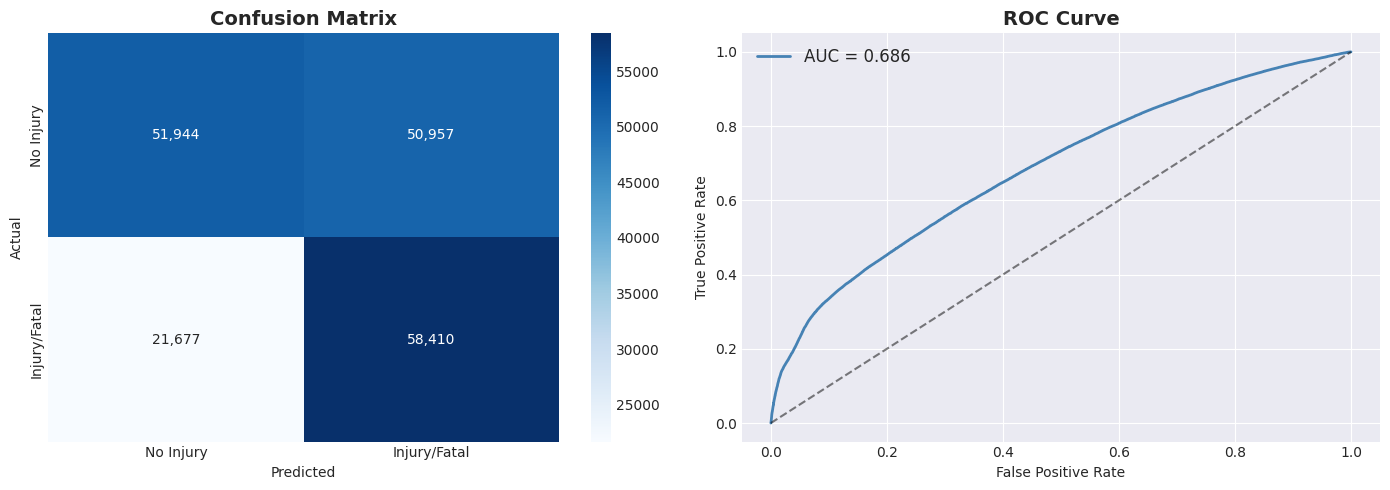

In [9]:
# Classification report and confusion matrix
print('LOGISTIC REGRESSION — CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['No Injury', 'Injury/Fatal']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['No Injury', 'Injury/Fatal'],
            yticklabels=['No Injury', 'Injury/Fatal'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

The Logistic Regression achieves 60.0% accuracy, with precision of 0.53 and recall of 0.73 for the Injury/Fatal class (F1 = 0.62). This is a meaningful result for our EMS stakeholder: the model catches 73% of all injury collisions, which is critical because failing to position resources near an actual severe crash has life-or-death consequences. The trade-off is lower precision (0.53), meaning some predicted injury cases turn out to be property-damage-only — an acceptable cost for EMS.
This substantially outperforms the naive baseline (always predicting majority class), which achieves 56.2% accuracy but zero recall for the injury class. Performance is relatively consistent across boroughs, suggesting the model generalizes across NYC's diverse neighborhoods.

### Feature Importance

The Logistic Regression coefficients reveal which factors most strongly predict injury severity. The following chart shows the top 20 features:

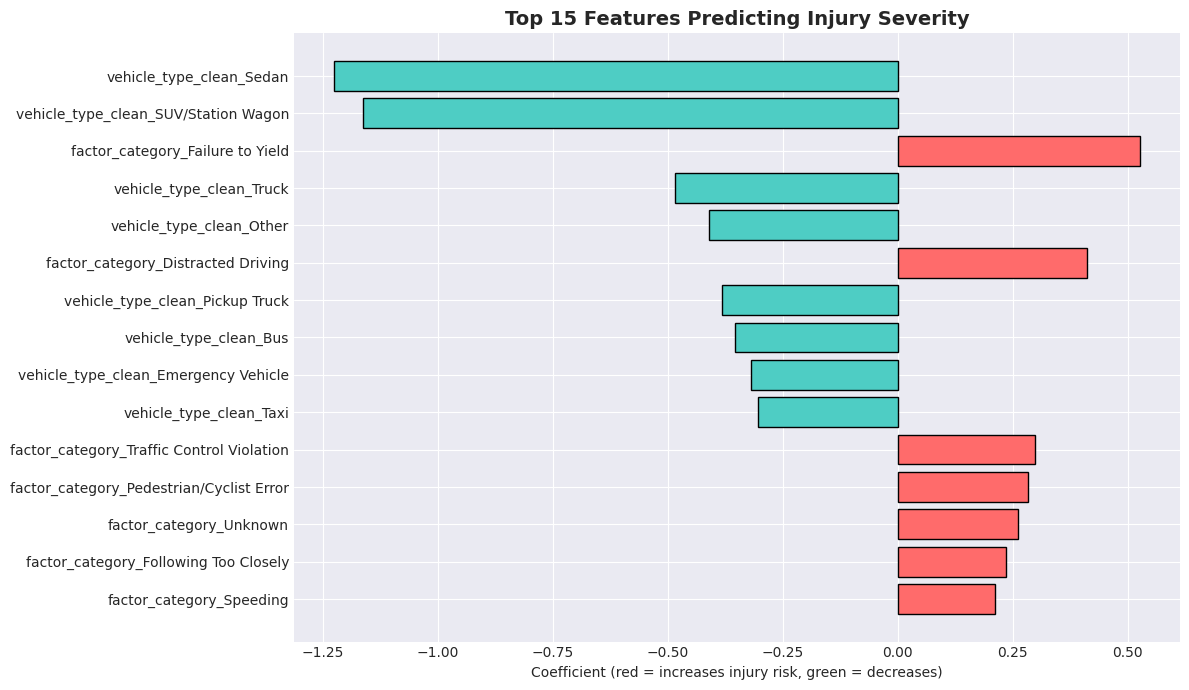

In [10]:
# Feature importance
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

top_n = 15
top_features = coef_df.head(top_n)

plt.figure(figsize=(12, 7))
colors = ['#FF6B6B' if c > 0 else '#4ECDC4' for c in top_features['Coefficient']]
plt.barh(range(top_n), top_features['Coefficient'].values, color=colors, edgecolor='black')
plt.yticks(range(top_n), top_features['Feature'].values)
plt.title('Top 15 Features Predicting Injury Severity', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient (red = increases injury risk, green = decreases)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Key findings from feature importance: **Failure to Yield** and **Distracted Driving** are the strongest positive predictors of injury (increasing severity risk), while **Sedan** and **SUV/Station Wagon** vehicle types have large negative coefficients — likely because these common vehicles are involved in many minor fender-benders that dilute the injury rate. Motorcycles and bicycles show higher injury associations, consistent with the vulnerability of these road users.

### Poisson Regression (Collision Counts)

As a complementary model, we fit a Poisson Regression to predict collision *counts* per borough-hour-day-month group. This addresses a different EMS question: not "will this crash be severe?" but "how many crashes should we expect in this area at this time?" The model achieves a MAE of 3.47 against a mean count of 7.79 (44.6% error). Brooklyn and the "Unknown" borough group have the highest collision rates, while Staten Island and weekends show significantly fewer collisions.

## Problems & Challenges

**1. Missing Borough Information (28.7%).** Over 107,000 records lack borough data, and our ZIP-code-based recovery approach was unable to fill any of these gaps (the records missing borough also lacked ZIP codes). This affects our spatial analysis and means the model's borough-level features are unavailable for a significant portion of the data. We handle this with an "Unknown" borough category, but this is a limitation.

**2. Moderate Model Performance.** Our baseline Logistic Regression achieves only 50.5% recall for injury collisions — meaning we miss about half of all injury crashes. For an EMS stakeholder where missing a severe crash has serious consequences, this needs substantial improvement. We plan to address this with ensemble methods (Random Forest, XGBoost) and threshold tuning to trade precision for recall.

**3. Class Imbalance in Fatal Crashes.** While the overall Injury/Fatal vs. Property Damage split is manageable (42:58), fatal crashes specifically are extremely rare (0.27%). Our current binary target groups Injury and Fatal together, but EMS may benefit from a model specifically targeting fatality prediction, which would require specialized techniques for rare-event classification.

**4. Large File Sizes.** The encoded feature matrices exceeded GitHub's 100MB file limit, requiring us to restructure our data pipeline and add generated files to `.gitignore`. This was a workflow challenge rather than a modeling one, but it caused some coordination difficulties across the team.

## Next Steps

| Target Date | Task | Details |
|-------------|------|---------|
| Mar 3–9 | Implement Random Forest and XGBoost | Expect significant improvement over Logistic Regression baseline for non-linear patterns |
| Mar 3–9 | Apply SMOTE/ADASYN | Address class imbalance and improve recall for injury prediction |
| Mar 10–16 | Hyperparameter tuning | Grid search / cross-validation for best model configuration |
| Mar 10–16 | Threshold optimization | Tune classification threshold to maximize recall for EMS use case |
| Mar 17–23 | Explore LSTM for temporal modeling | Per instructor feedback — capture sequential patterns in collision timing |
| Mar 24–30 | EMS deployment optimization | Model how to position ambulances based on predicted risk zones and times |
| Mar 31–Apr 13 | Dashboard and final report | Interactive risk heatmap, final model comparison, presentation |

Our immediate priority is improving recall on the injury class, since EMS cannot afford to miss high-risk periods. We expect tree-based ensemble methods to capture non-linear interactions (e.g., specific borough × time-of-day combinations) that Logistic Regression cannot model. Longer-term, the LSTM exploration could enable genuine time-series forecasting of collision risk.

### References:

- [1] Chen et al., "Road traffic safety analysis based on a GIS-based system," *Int. J. Transportation* (2020).
- [2] Plug et al., "Spatial and temporal visualisation techniques for crash analysis," *Accident Analysis & Prevention* (2011).
- [3] Anderson, "Kernel density estimation and K-means clustering to profile road accident hotspots," *Accident Analysis & Prevention* (2009).
- [4] Wang et al., "Short-term traffic accident prediction based on ARIMA," *Transportation Research Record* (2018).